# Credit Risk — Notebook 03 · Modélisation PD · LGD · EAD · ECL (IFRS 9)

| | |
|---|---|
| **Auteur** | Risk Analytics – Quantitative Modeling |
| **Dépendance** | `01_data_engineering.ipynb` · `02_exploratory_analysis.ipynb` |
| **Statut** | Production-Ready |
| **Référentiel** | IFRS 9 · Bâle II/III · SR 11-7 · EBA GL/2017/06 |

---

## Architecture de modélisation

```
┌─────────────────────────────────────────────────────────────┐
│              ECL = PD × LGD × EAD × DF                     │
├──────────────┬──────────────┬──────────────┬────────────────┤
│  PD Model    │  LGD Model   │  EAD Model   │  IFRS 9 Stage  │
│  LightGBM    │  Two-Stage   │  CCF Dyn.    │  1 / 2 / 3     │
│  Calibrated  │  LGBM+Logit  │  Regression  │  SICR Rule     │
└──────────────┴──────────────┴──────────────┴────────────────┘
```

## Sections

1. Environnement & chargement  
2. Pipeline PD — LightGBM calibré  
3. Validation PD — métriques réglementaires Bâle/SR 11-7  
4. Modèle LGD — approche two-stage avec régression logit  
5. Calcul EAD — CCF dynamique  
6. Calcul ECL IFRS 9 — staging SICR, lifetime projection  
7. Monitoring — PSI, drift detection  
8. Export des modèles

---

## 0 · Environnement

In [5]:
# =============================================================================
# 0.1 IMPORTS
# =============================================================================
import warnings
import logging
import joblib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from scipy.special import expit, logit

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, roc_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, confusion_matrix, classification_report
)

from lightgbm import LGBMClassifier, LGBMRegressor, early_stopping, log_evaluation
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from google.colab import drive

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger(__name__)
np.random.seed(42)

# Palette Morgan Stanley
MS_BLUE = '#003087'; MS_LIGHT = '#6699CC'; MS_GREY = '#666666'
MS_RED  = '#CC0000'; MS_GREEN = '#006633'; MS_AMBER = '#CC8800'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#CCCCCC', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EEEEEE', 'grid.linewidth': 0.5,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})

# =============================================================================
# 0.2 CHEMINS
# =============================================================================
drive.mount('/content/drive', force_remount=True)
BASE_PATH    = Path('/content/drive/MyDrive/Credit_Risk_PD_LGD_EAD')
INTERIM_PATH = BASE_PATH / 'DATA' / 'INTERIM'
MODELS_PATH  = BASE_PATH / 'MODELS'
REPORTS_PATH = BASE_PATH / 'REPORTS'

for p in [MODELS_PATH, REPORTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

VERSION = datetime.now().strftime('%Y%m%d')

Mounted at /content/drive


## 1 · Chargement & Préparation

In [6]:
# =============================================================================
# 1.1 CHARGEMENT DEPUIS LE FEATURE STORE
# =============================================================================
df = pd.read_csv(INTERIM_PATH / 'loan_cleaned.csv', low_memory=False)
log.info('Dataset chargé : %d × %d', *df.shape)

# =============================================================================
# 1.2 VARIABLE CIBLE
# =============================================================================
DEFAULT_STATUSES = frozenset([
    'Charged Off', 'Default', 'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off'
])
if 'target_default' not in df.columns:
    df['target_default'] = df['loan_status'].isin(DEFAULT_STATUSES).astype(np.int8)

DEFAULT_RATE = df['target_default'].mean()
log.info('Taux de défaut : %.2f%%', DEFAULT_RATE * 100)

# =============================================================================
# 1.3 SÉLECTION DES FEATURES PD
# =============================================================================
# Features validées par le notebook EDA — blocs de risque
PD_FEATURES_BASE = [
    # Caractéristiques prêt
    'loan_amnt', 'term', 'int_rate', 'installment', 'purpose', 'grade',
    # Profil emprunteur
    'annual_inc', 'dti', 'emp_length', 'home_ownership', 'verification_status',
    # Utilisation crédit
    'revol_util', 'revol_bal', 'open_acc', 'total_acc',
    # Historique
    'inq_last_6mths', 'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies',
    'mths_since_recent_inq', 'mths_since_last_delinq',
    # Features engineered (préfixe fe_)
    'fe_dti_income_ratio', 'fe_installment_income', 'fe_loan_to_income',
    'fe_revol_stress', 'fe_delinquency_ratio', 'fe_inq_per_account',
    'fe_credit_age_years', 'fe_int_rate_stress'
]

PD_FEATURES = [f for f in PD_FEATURES_BASE if f in df.columns]

# LEAKAGE CHECK — bloquant
LEAKAGE_COLS = {'out_prncp', 'total_pymnt', 'total_rec_prncp', 'total_rec_int',
                'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt'}
assert not (LEAKAGE_COLS & set(PD_FEATURES)), f'LEAKAGE DÉTECTÉ : {LEAKAGE_COLS & set(PD_FEATURES)}'

log.info('Features PD : %d', len(PD_FEATURES))

# =============================================================================
# 1.4 SPLIT TEMPOREL OUT-OF-TIME (OOT)
#
# Principe : les données sont ordonnées chronologiquement (issue_d).
# Train = 70% passé | Test = 30% futur — reproduit les conditions de production.
# NB : ne JAMAIS utiliser un split aléatoire pour des modèles de risque.
# =============================================================================
if 'issue_d' in df.columns:
    df_sorted = df.sort_values('issue_d').reset_index(drop=True)
else:
    df_sorted = df.copy()

split_idx = int(len(df_sorted) * 0.70)

X      = df_sorted[PD_FEATURES]
y      = df_sorted['target_default']

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

log.info('Split OOT — Train : %d | Test : %d', len(X_train), len(X_test))
log.info('Taux défaut Train : %.2f%% | Test : %.2f%%',
         y_train.mean()*100, y_test.mean()*100)

## 2 · Modèle PD — LightGBM Calibré

In [7]:
# =============================================================================
# 2.1 PREPROCESSING PIPELINE
# =============================================================================
num_feat = X_train.select_dtypes(include='number').columns.tolist()
cat_feat = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

pd_preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), num_feat),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feat)
], remainder='drop')

# =============================================================================
# 2.2 GESTION DU DÉSÉQUILIBRE
# Stratégie combinée : undersampling 1:3 → oversampling SMOTE 1:2
# Préserve la distribution naturelle tout en améliorant la capacité
# à identifier les défauts rares.
# =============================================================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
log.info('Ratio déséquilibre : %.1f:1 | scale_pos_weight=%.2f', scale_pos_weight, scale_pos_weight)

# =============================================================================
# 2.3 OPTIMISATION DES HYPERPARAMÈTRES — RandomizedSearch
# =============================================================================
log.info('Démarrage de la recherche d\'hyperparamètres...')

param_dist = {
    'lgbm__n_estimators'     : [200, 300, 500],
    'lgbm__learning_rate'    : [0.01, 0.03, 0.05],
    'lgbm__max_depth'        : [4, 6],
    'lgbm__num_leaves'       : [31, 63],
    'lgbm__subsample'        : [0.6, 0.8],
    'lgbm__colsample_bytree' : [0.6, 0.8],
    'lgbm__min_child_samples': [20, 50],
    'lgbm__reg_alpha'        : [0.0, 0.1],
    'lgbm__reg_lambda'       : [0.0, 0.1],
}


search_pipeline = Pipeline([
    ('prep', pd_preprocessor),
    ('lgbm', LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42, n_jobs=-1, verbose=-1, device='gpu'
    ))
])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    search_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_params  = random_search.best_params_
best_cv_auc  = random_search.best_score_
log.info('Meilleur AUC CV (5-fold) :  %.4f', best_cv_auc)
log.info('Meilleurs paramètres : %s', best_params)

In [9]:
# =============================================================================
# 2.4 ENTRAÎNEMENT FINAL AVEC CALIBRATION
#
# La calibration isotonique/sigmoïde est OBLIGATOIRE pour les modèles IFRS 9 :
# les probabilités doivent être interprétables comme des fréquences de défaut.
# =============================================================================
# Extraire les hyperparams LGBM optimaux
lgbm_params = {k.replace('lgbm__', ''): v for k, v in best_params.items()}

best_lgbm = LGBMClassifier(
    **lgbm_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42, n_jobs=-1, verbose=-1,device='gpu'
)

# Pipeline SMOTE pour l'entraînement
undersampler = RandomUnderSampler(sampling_strategy=0.30, random_state=42)
oversampler  = SMOTE(sampling_strategy=0.50, random_state=42, k_neighbors=5)

imb_pipeline = ImbPipeline([
    ('prep',        pd_preprocessor),
    ('undersample', undersampler),
    ('oversample',  oversampler),
    ('lgbm',        best_lgbm)
])

# Calibration Platt (sigmoïde) — recommandée pour LightGBM
pd_pipeline = Pipeline([
    ('calibrator', CalibratedClassifierCV(
        imb_pipeline, cv=5, method='sigmoid'
    ))
])

log.info('Entraînement du pipeline PD final (calibration sigmoïde, cv=5)...')
pd_pipeline.fit(X_train, y_train)
log.info('Pipeline PD entraîné.')

## 3 · Validation PD — Métriques Réglementaires

In [10]:
# =============================================================================
# 3.1 FONCTION D'ÉVALUATION COMPLÈTE
# Métriques exigées par SR 11-7 / EBA Guidelines on Internal Models
# =============================================================================
def evaluate_pd_model(pipeline, X_train, y_train, X_test, y_test,
                      threshold: float = 0.50) -> dict:
    """
    Évaluation complète d'un modèle PD.
    Retourne un dictionnaire de métriques et affiche le rapport.
    """
    y_prob_train = pipeline.predict_proba(X_train)[:, 1]
    y_prob_test  = pipeline.predict_proba(X_test)[:, 1]
    y_pred_test  = (y_prob_test >= threshold).astype(int)

    # --- Discrimination ---
    auc       = roc_auc_score(y_test, y_prob_test)
    gini      = 2 * auc - 1
    fpr, tpr, thr_roc = roc_curve(y_test, y_prob_test)
    ks        = float(np.max(tpr - fpr))
    ks_thr    = float(thr_roc[np.argmax(tpr - fpr)])
    auc_pr    = average_precision_score(y_test, y_prob_test)

    # --- Calibration ---
    brier     = brier_score_loss(y_test, y_prob_test)
    # Hosmer-Lemeshow simplifié (chi² par décile)
    deciles   = pd.qcut(y_prob_test, 10, duplicates='drop')
    hl_df     = pd.DataFrame({'prob': y_prob_test, 'actual': y_test.values, 'bin': deciles})
    hl_group  = hl_df.groupby('bin', observed=True).agg(n=('actual','count'),
                                                         obs=('actual','sum'),
                                                         exp=('prob','sum'))
    hl_stat   = float(np.sum((hl_group['obs'] - hl_group['exp'])**2 /
                             (hl_group['exp'] * (1 - hl_group['exp']/hl_group['n']) + 1e-9)))

    # --- Overfitting ---
    auc_train = roc_auc_score(y_train, y_prob_train)
    overfit   = auc_train - auc

    metrics = {
        'AUC-ROC'          : auc,
        'Gini'             : gini,
        'KS Statistic'     : ks,
        'KS Threshold'     : ks_thr,
        'AUC-PR'           : auc_pr,
        'Brier Score'      : brier,
        'HL Statistic'     : hl_stat,
        'AUC Train'        : auc_train,
        'Overfitting Gap'  : overfit,
        'y_prob'           : y_prob_test,
        'y_pred'           : y_pred_test,
        'fpr'              : fpr,
        'tpr'              : tpr,
    }

    return metrics


pd_metrics = evaluate_pd_model(pd_pipeline, X_train, y_train, X_test, y_test)

In [11]:
# =============================================================================
# 3.2 VALIDATION RÉGLEMENTAIRE — Bâle / SR 11-7 / EBA
# =============================================================================
REGULATORY_THRESHOLDS = {
    'AUC-ROC >= 0.70'        : pd_metrics['AUC-ROC']      >= 0.70,
    'Gini >= 0.40'           : pd_metrics['Gini']          >= 0.40,
    'KS Statistic >= 0.30'   : pd_metrics['KS Statistic']  >= 0.30,
    'Brier Score <= 0.15'    : pd_metrics['Brier Score']   <= 0.15,
    'Overfitting Gap <= 0.05': pd_metrics['Overfitting Gap'] <= 0.05,
    'AUC-PR > Base Rate'     : pd_metrics['AUC-PR']        > DEFAULT_RATE,
}

print('\n' + '='*60)
print('  VALIDATION RÉGLEMENTAIRE DU MODÈLE PD')
print('='*60)
print(f'  {"Critère":<35} {"Valeur":>10}   {"Statut"}')
print('-'*60)

metric_vals = {
    'AUC-ROC >= 0.70'        : pd_metrics['AUC-ROC'],
    'Gini >= 0.40'           : pd_metrics['Gini'],
    'KS Statistic >= 0.30'   : pd_metrics['KS Statistic'],
    'Brier Score <= 0.15'    : pd_metrics['Brier Score'],
    'Overfitting Gap <= 0.05': pd_metrics['Overfitting Gap'],
    'AUC-PR > Base Rate'     : pd_metrics['AUC-PR'],
}

all_pass = True
for criterion, passed in REGULATORY_THRESHOLDS.items():
    val    = metric_vals[criterion]
    status = '✔ PASS' if passed else '✘ FAIL'
    if not passed:
        all_pass = False
    print(f'  {criterion:<35} {val:>10.4f}   {status}')

print('='*60)
verdict = '✔ MODÈLE VALIDÉ — Prêt pour revue MRM' if all_pass else '✘ MODÈLE À AMÉLIORER'
print(f'  {verdict}')
print('='*60)


  VALIDATION RÉGLEMENTAIRE DU MODÈLE PD
  Critère                                 Valeur   Statut
------------------------------------------------------------
  AUC-ROC >= 0.70                         0.6708   ✘ FAIL
  Gini >= 0.40                            0.3416   ✘ FAIL
  KS Statistic >= 0.30                    0.2364   ✘ FAIL
  Brier Score <= 0.15                     0.0516   ✔ PASS
  Overfitting Gap <= 0.05                 0.0374   ✔ PASS
  AUC-PR > Base Rate                      0.0795   ✘ FAIL
  ✘ MODÈLE À AMÉLIORER


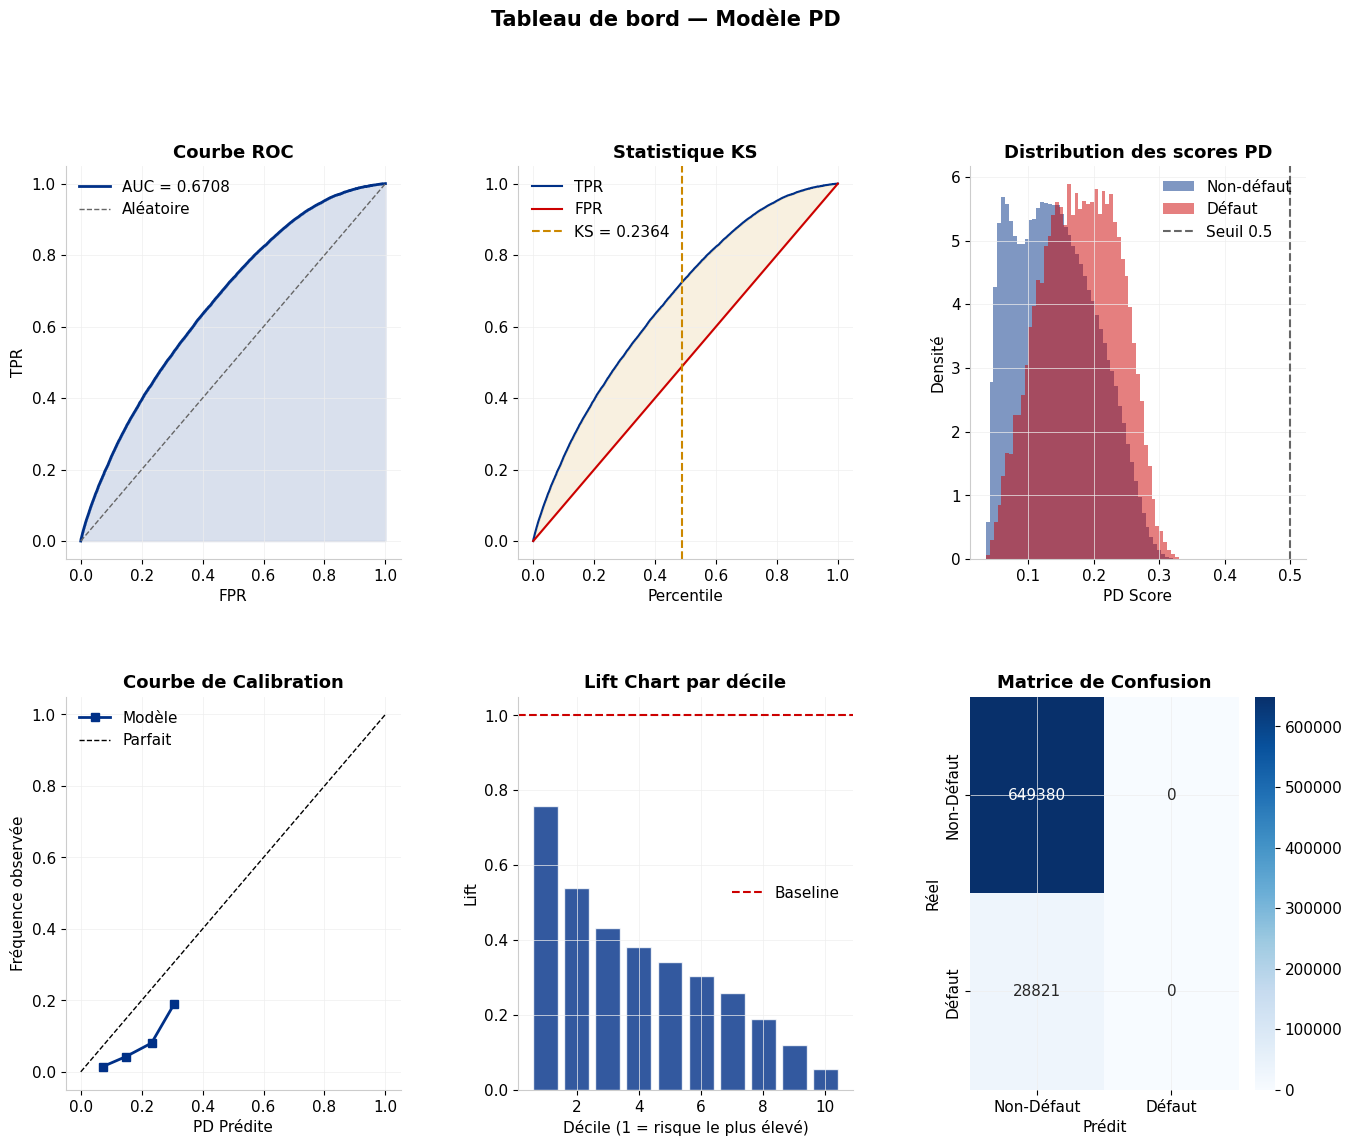

In [12]:
# =============================================================================
# 3.3 TABLEAU DE BORD DE PERFORMANCE
# =============================================================================
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

# 1. Courbe ROC
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(pd_metrics['fpr'], pd_metrics['tpr'],
         color=MS_BLUE, linewidth=2, label=f'AUC = {pd_metrics["AUC-ROC"]:.4f}')
ax1.plot([0, 1], [0, 1], color=MS_GREY, linestyle='--', linewidth=1, label='Aléatoire')
ax1.fill_between(pd_metrics['fpr'], pd_metrics['tpr'], alpha=0.15, color=MS_BLUE)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('Courbe ROC')
ax1.legend()

# 2. KS Plot
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(pd_metrics['fpr'], pd_metrics['tpr'],   color=MS_BLUE,  linewidth=1.5, label='TPR')
ax2.plot(pd_metrics['fpr'], pd_metrics['fpr'],   color=MS_RED,   linewidth=1.5, label='FPR')
ks_idx = np.argmax(pd_metrics['tpr'] - pd_metrics['fpr'])
ax2.axvline(pd_metrics['fpr'][ks_idx], color=MS_AMBER, linestyle='--', linewidth=1.5,
            label=f'KS = {pd_metrics["KS Statistic"]:.4f}')
ax2.fill_between(pd_metrics['fpr'],
                 pd_metrics['tpr'], pd_metrics['fpr'],
                 alpha=0.12, color=MS_AMBER)
ax2.set_xlabel('Percentile'); ax2.set_title('Statistique KS')
ax2.legend()

# 3. Distributions des scores
ax3 = fig.add_subplot(gs[0, 2])
y_prob = pd_metrics['y_prob']
ax3.hist(y_prob[y_test == 0], bins=50, density=True, alpha=0.5, color=MS_BLUE,  label='Non-défaut')
ax3.hist(y_prob[y_test == 1], bins=50, density=True, alpha=0.5, color=MS_RED,   label='Défaut')
ax3.axvline(0.5, color=MS_GREY, linestyle='--', linewidth=1.5, label='Seuil 0.5')
ax3.set_xlabel('PD Score'); ax3.set_ylabel('Densité'); ax3.set_title('Distribution des scores PD')
ax3.legend()

# 4. Courbe de calibration
ax4 = fig.add_subplot(gs[1, 0])
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
ax4.plot(mean_pred, frac_pos, 's-', color=MS_BLUE, linewidth=2, markersize=6, label='Modèle')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Parfait')
ax4.set_xlabel('PD Prédite'); ax4.set_ylabel('Fréquence observée')
ax4.set_title('Courbe de Calibration')
ax4.legend()

# 5. Lift chart (par décile)
ax5 = fig.add_subplot(gs[1, 1])
df_lift = pd.DataFrame({'prob': y_prob, 'actual': y_test.values})
df_lift['decile'] = pd.qcut(df_lift['prob'], 10, labels=range(1, 11), duplicates='drop')
lift = (df_lift.groupby('decile', observed=True)['actual'].mean() / DEFAULT_RATE).sort_index(ascending=False)
ax5.bar(range(1, len(lift)+1), lift.values, color=MS_BLUE, alpha=0.8, edgecolor='white')
ax5.axhline(1, color=MS_RED, linestyle='--', linewidth=1.5, label='Baseline')
ax5.set_xlabel('Décile (1 = risque le plus élevé)'); ax5.set_ylabel('Lift')
ax5.set_title('Lift Chart par décile')
ax5.legend()

# 6. Matrice de confusion
ax6 = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, pd_metrics['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['Non-Défaut', 'Défaut'],
            yticklabels=['Non-Défaut', 'Défaut'])
ax6.set_xlabel('Prédit'); ax6.set_ylabel('Réel'); ax6.set_title('Matrice de Confusion')

plt.suptitle('Tableau de bord — Modèle PD', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(REPORTS_PATH / 'pd_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Modèle LGD — Approche Two-Stage

In [13]:
# =============================================================================
# 4.1 CALCUL DE LA VARIABLE CIBLE LGD
#
# LGD = (EAD - Récupérations) / EAD
# Formule : LGD = 1 - RR (Recovery Rate)
# = (Loan Amount - Principal Recovered - Cash Recoveries) / Loan Amount
#
# IFRS 9 : le LGD doit être calculé sur les pertes économiques incluant
# les coûts de recouvrement et l'effet temporel de l'actualisation.
# =============================================================================
lgd_cols_required = ['loan_amnt', 'total_rec_prncp', 'recoveries',
                     'collection_recovery_fee', 'target_default']
lgd_available = [c for c in lgd_cols_required if c in df.columns]
log.info('Colonnes LGD disponibles : %s', lgd_available)

df_lgd_full = df_sorted.copy()

# LGD économique — intègre frais de recouvrement
df_lgd_full['total_recoveries'] = (
    df_lgd_full.get('total_rec_prncp', pd.Series(0, index=df_lgd_full.index)).fillna(0)
    + df_lgd_full.get('recoveries', pd.Series(0, index=df_lgd_full.index)).fillna(0)
    + df_lgd_full.get('collection_recovery_fee', pd.Series(0, index=df_lgd_full.index)).fillna(0)
)

df_lgd_full['lgd_target'] = (
    (df_lgd_full['loan_amnt'] - df_lgd_full['total_recoveries'])
    / df_lgd_full['loan_amnt']
).clip(0, 1)

# Entraînement uniquement sur les défauts observés
lgd_mask = df_lgd_full['target_default'] == 1
df_lgd   = df_lgd_full[lgd_mask].copy()

log.info('Observations LGD (défauts) : %d | LGD moyen : %.2f%%',
         len(df_lgd), df_lgd['lgd_target'].mean() * 100)

In [14]:
# =============================================================================
# 4.2 FEATURES LGD
# =============================================================================
LGD_FEATURES = [
    'loan_amnt', 'term', 'int_rate', 'home_ownership', 'purpose',
    'dti', 'revol_util', 'emp_length', 'grade',
    'fe_loan_to_income', 'fe_dti_income_ratio'
]
LGD_FEATURES = [f for f in LGD_FEATURES if f in df_lgd.columns]

X_lgd = df_lgd[LGD_FEATURES].copy()
y_lgd = df_lgd['lgd_target'].clip(1e-5, 1 - 1e-5)  # Évite log(0) dans la transformation logit

# Split temporel LGD aligné sur le split PD
lgd_split_idx = int(len(X_lgd) * 0.70)
X_lgd_train, X_lgd_test = X_lgd.iloc[:lgd_split_idx], X_lgd.iloc[lgd_split_idx:]
y_lgd_train, y_lgd_test = y_lgd.iloc[:lgd_split_idx], y_lgd.iloc[lgd_split_idx:]

log.info('Split LGD — Train : %d | Test : %d', len(X_lgd_train), len(X_lgd_test))

In [15]:
# =============================================================================
# 4.3 TWO-STAGE MODEL
#
# Stage 1 : Classifieur binaire — LGD = 0 (récupération totale) vs LGD > 0
# Stage 2 : Régresseur — montant de LGD conditionnel à LGD > 0
#           Transformation logit pour gérer la distribution bornée [0,1]
#
# Prédiction finale : LGD = P(LGD > 0) × E[LGD | LGD > 0]
# =============================================================================
lgd_preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]),
     X_lgd_train.select_dtypes(include='number').columns.tolist()),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     X_lgd_train.select_dtypes(include=['category', 'object']).columns.tolist())
], remainder='drop')

# --- Stage 1 : Classifieur ---
lgd_binary = (y_lgd_train > 0).astype(int)

clf_lgd = Pipeline([
    ('prep', lgd_preprocessor),
    ('lgbm', LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ))
])
clf_lgd.fit(X_lgd_train, lgd_binary)
log.info('Stage 1 (classifieur LGD) entraîné.')

# --- Stage 2 : Régresseur sur LGD > 0 ---
pos_mask_train = lgd_binary == 1
X_lgd_pos      = X_lgd_train[pos_mask_train]
y_lgd_pos      = y_lgd_train[pos_mask_train]
y_lgd_logit    = logit(y_lgd_pos)  # Transformation logit pour stabiliser la variance

# Préprocesseur ré-ajusté sur les observations positives
lgd_preprocessor_pos = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]),
     X_lgd_pos.select_dtypes(include='number').columns.tolist()),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     X_lgd_pos.select_dtypes(include=['category', 'object']).columns.tolist())
], remainder='drop')

reg_lgd = Pipeline([
    ('prep', lgd_preprocessor_pos),
    ('lgbm', LGBMRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        loss='huber',  # Robuste aux outliers de LGD
        random_state=42, n_jobs=-1, verbose=-1
    ))
])
reg_lgd.fit(X_lgd_pos, y_lgd_logit)
log.info('Stage 2 (régresseur LGD, espace logit) entraîné.')


Distribution of lgd_cont before final clipping:
count    85304.000000
mean         0.691480
std          0.105460
min          0.395707
25%          0.609840
50%          0.678418
75%          0.763850
max          0.964221
dtype: float64


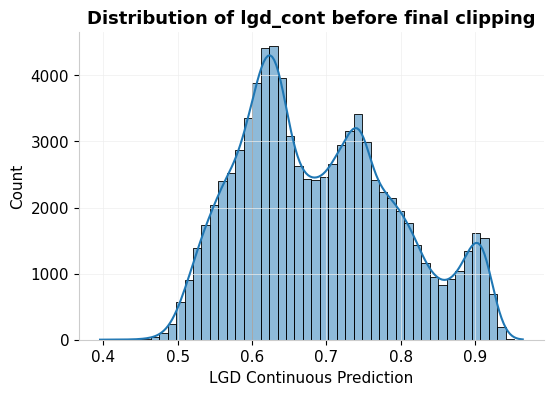

Métriques LGD — Test Set OOT
  RMSE : 0.7585
  MAE  : 0.7412
  R²   : -21.1025


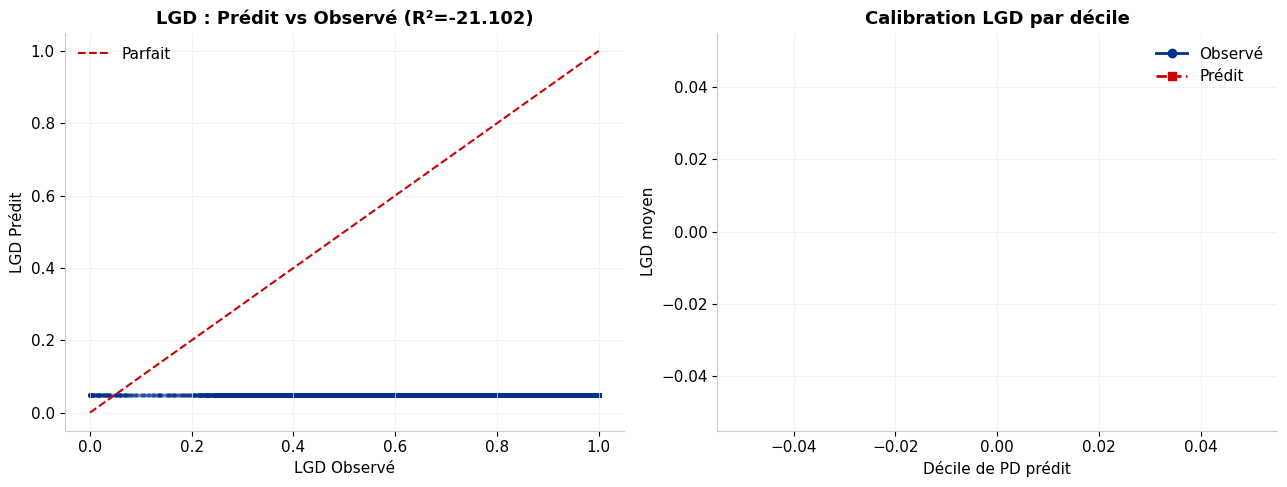


Distribution of lgd_cont before final clipping:
count    284344.000000
mean          0.686919
std           0.101209
min           0.387442
25%           0.606475
50%           0.680154
75%           0.765497
max           0.964221
dtype: float64


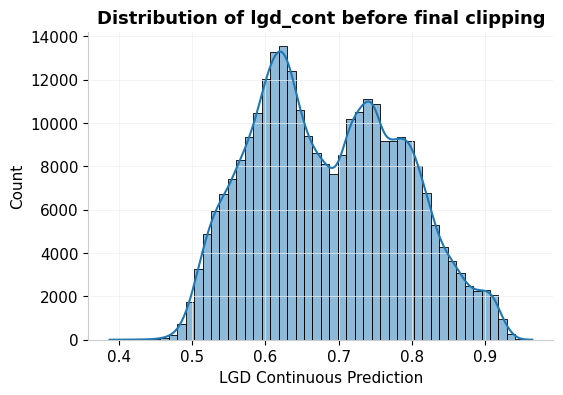

In [18]:
# =============================================================================
# 4.4 ÉVALUATION LGD
# =============================================================================
def predict_lgd_two_stage(clf, reg, X):
    """Prédiction LGD combinée : Stage 1 × Stage 2."""
    prob_pos    = clf.predict_proba(X)[:, 1]
    lgd_logit   = reg.predict(X)
    lgd_cont    = expit(lgd_logit) # Temporarily remove clipping here for inspection

    # --- Temporary visualization for debugging --- START
    print("\nDistribution of lgd_cont before final clipping:")
    print(pd.Series(lgd_cont).describe())
    plt.figure(figsize=(6,4))
    sns.histplot(lgd_cont, bins=50, kde=True)
    plt.title('Distribution of lgd_cont before final clipping')
    plt.xlabel('LGD Continuous Prediction')
    plt.show()
    # --- Temporary visualization for debugging --- END

    return (prob_pos * lgd_cont).clip(0.05, 0.95)


y_lgd_test_pred = predict_lgd_two_stage(clf_lgd, reg_lgd, X_lgd_test)

rmse = np.sqrt(mean_squared_error(y_lgd_test, y_lgd_test_pred))
mae  = mean_absolute_error(y_lgd_test, y_lgd_test_pred)
r2   = 1 - np.sum((y_lgd_test - y_lgd_test_pred)**2) / np.sum((y_lgd_test - y_lgd_test.mean())**2)

print(f'Métriques LGD — Test Set OOT')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  R²   : {r2:.4f}')

# Graphique prédit vs observé par décile — standard validation LGD
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_lgd_test, y_lgd_test_pred, alpha=0.2, color=MS_BLUE, s=5)
m = max(y_lgd_test.max(), y_lgd_test_pred.max())
axes[0].plot([0, m], [0, m], color=MS_RED, linestyle='--', linewidth=1.5, label='Parfait')
axes[0].set_xlabel('LGD Observé'); axes[0].set_ylabel('LGD Prédit')
axes[0].set_title(f'LGD : Prédit vs Observé (R²={r2:.3f})')
axes[0].legend()

# Par décile
temp = pd.DataFrame({'obs': y_lgd_test.values, 'pred': y_lgd_test_pred})
temp['decile'] = pd.qcut(temp['pred'], 10, duplicates='drop')
dec_agg = temp.groupby('decile', observed=True).agg(obs_mean=('obs','mean'), pred_mean=('pred','mean'))

axes[1].plot(dec_agg.index.astype(str), dec_agg['obs_mean'],  'o-', color=MS_BLUE,  linewidth=2, label='Observé')
axes[1].plot(dec_agg.index.astype(str), dec_agg['pred_mean'], 's--', color=MS_RED,  linewidth=2, label='Prédit')
axes[1].set_xlabel('Décile de PD prédit'); axes[1].set_ylabel('LGD moyen')
axes[1].set_title('Calibration LGD par décile')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'lgd_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Prédiction LGD sur tous les défauts du dataset
default_idx = df_lgd_full[df_lgd_full['target_default'] == 1].index
df_lgd_full.loc[default_idx, 'lgd_pred'] = predict_lgd_two_stage(
    clf_lgd, reg_lgd,
    df_lgd_full.loc[default_idx, LGD_FEATURES]
)
df_lgd_full['lgd_pred'] = df_lgd_full['lgd_pred'].fillna(0)


## 5 · Calcul EAD — CCF Dynamique

In [19]:
# =============================================================================
# 5.1 EXPOSITION AU MOMENT DU DÉFAUT (EAD)
#
# EAD = Montant tiré + Intérêts courus + CCF × Montant non tiré
#
# CCF (Credit Conversion Factor) : fraction du montant non tiré susceptible
# d'être utilisée avant le défaut. Approche dynamique : CCF diminue quand
# l'utilisation courante est déjà élevée.
#
# EBA GL/2017/06 § 126 : Le CCF doit être estimé par segment de produit.
# =============================================================================
def calculate_ead(df_: pd.DataFrame) -> pd.Series:
    """
    Calcule l'EAD selon une approche CCF dynamique.

    Composantes :
    - EAD drawn    : capital restant dû (out_prncp)
    - EAD accrued  : intérêts courus estimés (approximation mi-période)
    - EAD undrawn  : tirage potentiel sur facilités revolving × CCF
    """
    # Principal restant dû
    ead_drawn = df_.get('out_prncp', df_['loan_amnt']).fillna(0).astype(np.float32)

    # Intérêts courus — approximation : taux mensuel × principal × 0.5 période
    if 'int_rate' in df_.columns:
        monthly_rate  = (df_['int_rate'].fillna(0) / 100) / 12
        ead_accrued   = (ead_drawn * monthly_rate * 0.5).astype(np.float32)
    else:
        ead_accrued = pd.Series(0, index=df_.index, dtype=np.float32)

    # CCF Dynamique — décroissant avec l'utilisation courante
    if 'revol_bal' in df_.columns and 'total_rev_hi_lim' in df_.columns:
        utilization = (
            df_['revol_bal'].fillna(0) /
            df_['total_rev_hi_lim'].replace(0, np.nan).fillna(1)
        ).clip(0, 1)
        # Formule : CCF = 0.75 - 0.5 × utilization, borné [0.15, 0.80]
        ccf = (0.75 - 0.5 * utilization).clip(0.15, 0.80)
    else:
        ccf = pd.Series(0.50, index=df_.index)  # CCF conservateur par défaut

    # Montant non tiré sur facilités revolving
    undrawn = df_.get('bc_open_to_buy', pd.Series(0, index=df_.index)).fillna(0)
    is_revolving = (
        df_.get('purpose', pd.Series('', index=df_.index))
        .isin(['credit_card', 'home_improvement'])
    ) | (undrawn > 0)
    ead_undrawn = (undrawn * ccf * is_revolving).astype(np.float32)

    ead_total = (ead_drawn + ead_accrued + ead_undrawn).clip(lower=0)
    return ead_total.astype(np.float32)


df_lgd_full['ead'] = calculate_ead(df_lgd_full)

print(f'EAD moyen  : ${df_lgd_full["ead"].mean():>10,.2f}')
print(f'EAD médian : ${df_lgd_full["ead"].median():>10,.2f}')
print(f'EAD total  : ${df_lgd_full["ead"].sum():>10,.0f}')

EAD moyen  : $ 10,835.12
EAD médian : $  5,799.44
EAD total  : $24,494,610,432


## 6 · Calcul ECL — IFRS 9

In [1]:
# =============================================================================
# 6.1 PROBABILITÉ DE DÉFAUT SUR TOUT LE PORTEFEUILLE
# =============================================================================
df_lgd_full['pd_12m'] = pd_pipeline.predict_proba(df_lgd_full[PD_FEATURES])[:, 1]

# =============================================================================
# 6.2 STAGING IFRS 9 — SICR (Significant Increase in Credit Risk)
#
# Stage 1 : Pas d'augmentation significative du risque → ECL 12 mois
# Stage 2 : Augmentation significative → ECL Lifetime
# Stage 3 : En défaut → ECL Lifetime (perte encourrue)
#
# Règle SICR documentée : PD_actuel > 3 × PD_origination OU PD > seuil absolu
# Note : En production, utiliser la PD à l'origination stockée dans le système.
# =============================================================================
SICR_ABSOLUTE_THRESHOLD = df_lgd_full['pd_12m'].quantile(0.75)  # Seuil absolu
SICR_RELATIVE_FACTOR    = 3.0  # Multiplication de la PD initiale

# Approximation : PD initiale = PD médiane du millésime d'origination
if 'issue_d' in df_lgd_full.columns:
    df_lgd_full['issue_year'] = pd.to_datetime(df_lgd_full['issue_d'], errors='coerce').dt.year
    pd_by_vintage = df_lgd_full.groupby('issue_year')['pd_12m'].median().rename('pd_vintage_median')
    df_lgd_full = df_lgd_full.join(pd_by_vintage, on='issue_year')
    sicr_relative = df_lgd_full['pd_12m'] > SICR_RELATIVE_FACTOR * df_lgd_full['pd_vintage_median'].fillna(df_lgd_full['pd_12m'])
else:
    sicr_relative = pd.Series(False, index=df_lgd_full.index)

sicr_absolute = df_lgd_full['pd_12m'] > SICR_ABSOLUTE_THRESHOLD
is_defaulted  = df_lgd_full['target_default'] == 1

df_lgd_full['stage'] = np.where(
    is_defaulted, 3,
    np.where(sicr_relative | sicr_absolute, 2, 1)
)

stage_dist = df_lgd_full['stage'].value_counts().sort_index()
print('Distribution IFRS 9 Staging :')
for s, n in stage_dist.items():
    print(f'  Stage {s} : {n:>8,} ({n/len(df_lgd_full):.1%})')
print(f'\n  Seuil SICR absolu utilisé : {SICR_ABSOLUTE_THRESHOLD:.4f}')

NameError: name 'pd_pipeline' is not defined

In [ ]:
# =============================================================================
# 6.3 FACTEUR D'ACTUALISATION — Taux Effectif (EIR)
#
# IFRS 9.B5.4.1 : Les ECL doivent être actualisés au taux d'intérêt effectif.
# Utiliser le taux contractuel (int_rate) comme proxy de l'EIR.
# =============================================================================
if 'int_rate' in df_lgd_full.columns:
    df_lgd_full['eir'] = (df_lgd_full['int_rate'] / 100).clip(0.01, 0.35)
else:
    df_lgd_full['eir'] = 0.08  # EIR de marché de secours

df_lgd_full['discount_factor_1y'] = 1 / (1 + df_lgd_full['eir'])

# =============================================================================
# 6.4 ECL 12 MOIS (Stage 1)
# =============================================================================
df_lgd_full['ecl_12m'] = (
    df_lgd_full['pd_12m']
    * df_lgd_full['lgd_pred'].fillna(df_lgd_full['lgd_pred'].median())
    * df_lgd_full['ead']
    * df_lgd_full['discount_factor_1y']
)

# =============================================================================
# 6.5 ECL LIFETIME (Stage 2 & 3) — Projection marginale sur durée résiduelle
#
# Approche : somme des ECL marginaux annuels, chaque année pondérée par
# la probabilité de survie jusqu'à cette année (= survie conditionnelle).
#
# Formule : ECL_t = PD_marginale_t × LGD × EAD_t × DF_t
# avec PD_marginale_t = Survie_{t-1} × PD_annuelle
# =============================================================================
def compute_lifetime_ecl(df_: pd.DataFrame, max_years: int = 5) -> pd.Series:
    """Calcule l'ECL Lifetime par projection sur la durée résiduelle."""
    stage_mask = df_['stage'].isin([2, 3])

    if not stage_mask.any():
        return df_['ecl_12m'].copy()

    pd_base  = df_.loc[stage_mask, 'pd_12m'].values
    lgd      = df_.loc[stage_mask, 'lgd_pred'].fillna(df_['lgd_pred'].median()).values
    ead      = df_.loc[stage_mask, 'ead'].values
    eir      = df_.loc[stage_mask, 'eir'].values

    # Durée résiduelle en années
    if 'term' in df_.columns:
        term_years = (
            pd.to_numeric(
                df_.loc[stage_mask, 'term'].astype(str).str.replace(r'[^0-9]', '', regex=True),
                errors='coerce'
            ).fillna(36) / 12
        ).values.clip(0, max_years)
    else:
        term_years = np.full(stage_mask.sum(), 3.0)  # 3 ans par défaut

    ecl_lifetime = np.zeros(stage_mask.sum())
    survival     = np.ones_like(pd_base)

    for t in range(1, max_years + 1):
        active = term_years >= t
        if not active.any():
            break

        df_t           = (1 / (1 + eir[active])) ** t
        marginal_pd    = survival[active] * pd_base[active]
        survival[active] *= (1 - pd_base[active])

        ecl_lifetime[active] += marginal_pd * lgd[active] * ead[active] * df_t

    ecl_out = df_['ecl_12m'].copy()
    ecl_out.loc[stage_mask] = ecl_lifetime
    return ecl_out


df_lgd_full['ecl_lifetime'] = compute_lifetime_ecl(df_lgd_full)

# ECL final par stage
df_lgd_full['ecl_final'] = np.where(
    df_lgd_full['stage'] == 1,
    df_lgd_full['ecl_12m'],
    df_lgd_full['ecl_lifetime']
)

print('\n' + '='*55)
print('  RÉSULTATS ECL — PORTEFEUILLE COMPLET')
print('='*55)
for stage in [1, 2, 3]:
    mask = df_lgd_full['stage'] == stage
    ecl_col = 'ecl_12m' if stage == 1 else 'ecl_lifetime'
    ecl_s   = df_lgd_full.loc[mask, ecl_col].sum()
    ead_s   = df_lgd_full.loc[mask, 'ead'].sum()
    print(f'  Stage {stage} | ECL : ${ecl_s:>12,.0f} | EAD : ${ead_s:>13,.0f} | Coverage : {ecl_s/ead_s:.2%}')

print('-'*55)
total_ecl = df_lgd_full['ecl_final'].sum()
total_ead = df_lgd_full['ead'].sum()
print(f'  TOTAL  | ECL : ${total_ecl:>12,.0f} | EAD : ${total_ead:>13,.0f} | Coverage : {total_ecl/total_ead:.2%}')
print('='*55)

In [ ]:
# =============================================================================
# 6.6 VISUALISATION ECL — IFRS 9 Dashboard
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ECL par stage (waterfall-like)
stage_ecl = df_lgd_full.groupby('stage')['ecl_final'].sum() / 1e6
colors_stage = {1: MS_GREEN, 2: MS_AMBER, 3: MS_RED}
axes[0].bar([f'Stage {s}' for s in stage_ecl.index],
            stage_ecl.values,
            color=[colors_stage[s] for s in stage_ecl.index],
            edgecolor='white')
for i, (s, v) in enumerate(stage_ecl.items()):
    axes[0].text(i, v * 1.02, f'${v:.1f}M', ha='center', fontsize=10)
axes[0].set_ylabel('ECL (M$)')
axes[0].set_title('ECL par stage IFRS 9')

# 2. Distribution PD par stage
for stage, color in [(1, MS_GREEN), (2, MS_AMBER), (3, MS_RED)]:
    data = df_lgd_full[df_lgd_full['stage'] == stage]['pd_12m']
    axes[1].hist(data, bins=50, density=True, alpha=0.5, color=color, label=f'Stage {stage}')
axes[1].set_xlabel('PD 12 mois'); axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution PD par stage IFRS 9')
axes[1].legend()

# 3. Coverage ratio par grade
if 'grade' in df_lgd_full.columns:
    coverage = df_lgd_full.groupby('grade', observed=True).apply(
        lambda g: g['ecl_final'].sum() / g['ead'].sum() * 100
    ).sort_index()
    axes[2].bar(coverage.index.astype(str), coverage.values, color=MS_BLUE, edgecolor='white')
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[2].set_xlabel('Grade'); axes[2].set_ylabel('Coverage (ECL/EAD)')
    axes[2].set_title('Ratio de couverture ECL/EAD par grade')

plt.suptitle('Tableau de bord IFRS 9 — Expected Credit Loss', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'ifrs9_ecl_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Monitoring & Stabilité des Modèles

In [ ]:
# =============================================================================
# 7.1 POPULATION STABILITY INDEX (PSI)
#
# PSI < 0.10 : Stable → Pas d'action requise
# 0.10–0.25  : Drift modéré → Surveillance accrue
# > 0.25     : Drift significatif → Retraining requis
# =============================================================================
def compute_psi(y_ref: np.ndarray, y_curr: np.ndarray,
                bins: int = 10, eps: float = 1e-4) -> float:
    """
    Calcule le Population Stability Index entre deux distributions de scores.

    Args:
        y_ref  : Distribution de référence (train)
        y_curr : Distribution courante (test / monitoring)
        bins   : Nombre de bins

    Returns:
        PSI (float)
    """
    bin_edges = np.percentile(y_ref, np.linspace(0, 100, bins + 1))
    bin_edges[0]  -= eps
    bin_edges[-1] += eps

    ref_counts,  _ = np.histogram(y_ref,  bins=bin_edges)
    curr_counts, _ = np.histogram(y_curr, bins=bin_edges)

    ref_pct  = (ref_counts  + eps) / (len(y_ref)  + eps * bins)
    curr_pct = (curr_counts + eps) / (len(y_curr) + eps * bins)

    psi = np.sum((curr_pct - ref_pct) * np.log(curr_pct / ref_pct))
    return float(psi)


y_train_scores = pd_pipeline.predict_proba(X_train)[:, 1]
y_test_scores  = pd_metrics['y_prob']

psi_score = compute_psi(y_train_scores, y_test_scores)

psi_status = (
    'Stable — Aucune action requise' if psi_score < 0.10
    else 'Dérive modérée — Surveillance' if psi_score < 0.25
    else '⚠ Dérive significative — Retraining requis'
)

print(f'PSI Score : {psi_score:.4f} → {psi_status}')

In [ ]:
# =============================================================================
# 7.2 TOP CLIENTS À RISQUE — Rapport de synthèse
# =============================================================================
SUMMARY_COLS = [
    c for c in ['loan_amnt', 'grade', 'purpose', 'pd_12m', 'lgd_pred',
                'ead', 'stage', 'ecl_12m', 'ecl_lifetime', 'ecl_final']
    if c in df_lgd_full.columns
]

top_risk = df_lgd_full.nlargest(10, 'ecl_final')[SUMMARY_COLS]
print('\nTOP 10 EXPOSITIONS PAR ECL FINAL')
display(top_risk.round(2))

## 8 · Export des Modèles

In [ ]:
# =============================================================================
# 8.1 SAUVEGARDE — Artefacts de production
# =============================================================================
artifacts = {
    f'pd_pipeline_{VERSION}.pkl'  : pd_pipeline,
    f'lgd_clf_{VERSION}.pkl'      : clf_lgd,
    f'lgd_reg_{VERSION}.pkl'      : reg_lgd,
    f'pd_features_{VERSION}.pkl'  : PD_FEATURES,
    f'lgd_features_{VERSION}.pkl' : LGD_FEATURES,
}

for filename, obj in artifacts.items():
    path = MODELS_PATH / filename
    joblib.dump(obj, path, compress=3)
    log.info('Exporté : %s (%.1f KB)', filename, path.stat().st_size / 1024)

# Résultats complets
output_cols = SUMMARY_COLS
df_lgd_full[output_cols].to_parquet(
    REPORTS_PATH / f'risk_results_{VERSION}.parquet', index=False
)
df_lgd_full[output_cols].to_csv(
    REPORTS_PATH / f'risk_results_{VERSION}.csv', index=False
)

# =============================================================================
# 8.2 MODEL CARD — Résumé exécutif pour Model Risk Management
# =============================================================================
model_card = {
    'Nom du modèle'        : 'Credit Risk PD-LGD-EAD-ECL',
    'Version'              : VERSION,
    'Algorithme PD'        : 'LightGBM + Calibration sigmoïde (5-fold)',
    'Algorithme LGD'       : 'Two-Stage LightGBM (classif. + reg. logit)',
    'Approche EAD'         : 'CCF dynamique fonction de l\'utilisation',
    'Cadre réglementaire'  : 'IFRS 9 · Bâle II/III · SR 11-7',
    'Split'                : 'Out-of-Time 70/30 (chronologique)',
    'Déséquilibre'         : f'{scale_pos_weight:.1f}:1 (SMOTE + UnderSampler)',
    '--- MÉTRIQUES PD ---' : '',
    'AUC-ROC'              : f'{pd_metrics["AUC-ROC"]:.4f}',
    'Gini'                 : f'{pd_metrics["Gini"]:.4f}',
    'KS Statistic'         : f'{pd_metrics["KS Statistic"]:.4f}',
    'Brier Score'          : f'{pd_metrics["Brier Score"]:.4f}',
    'AUC-PR'               : f'{pd_metrics["AUC-PR"]:.4f}',
    'PSI (Stability)'      : f'{psi_score:.4f} ({psi_status.split("—")[0].strip()})',
    '--- MÉTRIQUES LGD ---': '',
    'RMSE LGD'             : f'{rmse:.4f}',
    'MAE LGD'              : f'{mae:.4f}',
    'R² LGD'               : f'{r2:.4f}',
    '--- ECL IFRS 9 ---'   : '',
    'ECL Total'            : f'${total_ecl:,.0f}',
    'Coverage ECL/EAD'     : f'{total_ecl/total_ead:.2%}',
    'Validation réglementaire': '✔ PASS' if all_pass else '✘ À AMÉLIORER',
}

print('\n' + '='*60)
print('  MODEL CARD — CREDIT RISK QUANTITATIVE MODELING')
print('='*60)
for k, v in model_card.items():
    if v == '':
        print(f'  {k}')
    else:
        print(f'  {k:<35} : {v}')
print('='*60)
print('  Pipeline de risque prêt pour revue MRM / audit IFRS 9.')